## Examen de Primer Bimestre — Sistema de Recuperación de Información


1. **Dependencias (Requirements):** Ejecute la primera celda de código para instalar todas las librerías necesarias. Esto funciona como el equivalente a un archivo `requirements.txt` integrado.
2. **Archivos de Datos:** Asegúrese de que los archivos de corpus (`rotten_tomatoes_movies.csv` y `rotten_tomatoes_critic_reviews.csv`) se encuentren ubicados exactamente en la **misma carpeta** que este notebook (ruta relativa local).
3. **Modelo de Embeddings:** El sistema utiliza **Word2Vec Google News 300**. Asegúrese de tener el archivo del modelo descargado y la ruta configurada en la celda correspondiente (Paso 3), o conexión a internet si se utiliza la API de `gensim` para descargarlo en memoria.
4. **Ejecución:** Seleccione en el menú superior de Jupyter: `Kernel` -> `Restart & Run All` para ejecutar todo el pipeline de principio a fin sin conflictos de memoria.

## Instalación de dependencias

In [69]:
# Instalamos las librerías necesarias para el examen (requirements)
# El modificador '-q' (quiet) hace que la instalación sea limpia visualmente.

!pip install -q gensim scikit-learn pandas numpy matplotlib seaborn nltk



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\AdminPC\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


# Importar librerias necesarias para el examen

In [70]:
import pandas as pd
import numpy as np
import re
import string
import warnings
warnings.filterwarnings('ignore')

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',  quiet=True)

# Word2Vec
import gensim.downloader as api

# Similitud y reducción dimensional
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

# Visualización
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

print('✅')

✅


## Carga del corpus

In [71]:
import pandas as pd

PATH_MOVIES  = 'rotten_tomatoes_movies.csv'
PATH_REVIEWS = 'rotten_tomatoes_critic_reviews.csv'

# Cargar los DataFrames
df_movies  = pd.read_csv(PATH_MOVIES,  low_memory=False)
df_reviews = pd.read_csv(PATH_REVIEWS, low_memory=False)

# Mostrar resultados
print(f'Movies  → {df_movies.shape[0]:,} filas | {df_movies.shape[1]} columnas')
print(f'Reviews → {df_reviews.shape[0]:,} filas | {df_reviews.shape[1]} columnas')
print()
print('Columnas movies: ',  list(df_movies.columns))
print('Columnas reviews:', list(df_reviews.columns))

Movies  → 17,712 filas | 22 columnas
Reviews → 1,130,017 filas | 8 columnas

Columnas movies:  ['rotten_tomatoes_link', 'movie_title', 'movie_info', 'critics_consensus', 'content_rating', 'genres', 'directors', 'authors', 'actors', 'original_release_date', 'streaming_release_date', 'runtime', 'production_company', 'tomatometer_status', 'tomatometer_rating', 'tomatometer_count', 'audience_status', 'audience_rating', 'audience_count', 'tomatometer_top_critics_count', 'tomatometer_fresh_critics_count', 'tomatometer_rotten_critics_count']
Columnas reviews: ['rotten_tomatoes_link', 'critic_name', 'top_critic', 'publisher_name', 'review_type', 'review_score', 'review_date', 'review_content']


In [72]:
df_movies.head(1)

,rotten_tomatoes_link,movie_title,movie_info,critics_consensus,content_rating,genres,directors,authors,actors,original_release_date,...,production_company,tomatometer_status,tomatometer_rating,tomatometer_count,audience_status,audience_rating,audience_count,tomatometer_top_critics_count,tomatometer_fresh_critics_count,tomatometer_rotten_critics_count
0,m/0814255,Percy Jackson & the Olympians: The Lightning T...,"Always trouble-prone, the life of teenager Per...",Though it may seem like just another Harry Pot...,PG,"Action & Adventure, Comedy, Drama, Science Fic...",Chris Columbus,"Craig Titley, Chris Columbus, Rick Riordan","Logan Lerman, Brandon T. Jackson, Alexandra Da...",2010-02-12,...,20th Century Fox,Rotten,49.0,149.0,Spilled,53.0,254421.0,43,73,76


In [73]:
df_reviews.head(1)

,rotten_tomatoes_link,critic_name,top_critic,publisher_name,review_type,review_score,review_date,review_content
0,m/0814255,Andrew L. Urban,False,Urban Cinefile,Fresh,NaN,2010-02-06,A fantasy adventure that fuses Greek mythology...


## Selección de campos textuales y construcción del corpus

**Estrategia de representación documental:**  
- movie_title — título
- genres — géneros
- movie_info — sinopsis/descripción
- critics_consensus — consenso de críticos


In [74]:
MOVIE_COLS = ['rotten_tomatoes_link', 'movie_title', 'genres', 'movie_info', 'critics_consensus']
available  = [c for c in MOVIE_COLS if c in df_movies.columns]
print('Columnas disponibles:', available)

df_corpus = df_movies[available].copy()

text_cols = [c for c in ['movie_info', 'critics_consensus'] if c in df_corpus.columns]
df_corpus.dropna(subset=text_cols, how='all', inplace=True)
df_corpus.reset_index(drop=True, inplace=True)

print(f'Documentos en corpus: {len(df_corpus):,}')
df_corpus.head(3)

Columnas disponibles: ['rotten_tomatoes_link', 'movie_title', 'genres', 'movie_info', 'critics_consensus']
Documentos en corpus: 17,486


,rotten_tomatoes_link,movie_title,genres,movie_info,critics_consensus
0,m/0814255,Percy Jackson & the Olympians: The Lightning T...,"Action & Adventure, Comedy, Drama, Science Fic...","Always trouble-prone, the life of teenager Per...",Though it may seem like just another Harry Pot...
1,m/0878835,Please Give,Comedy,Kate (Catherine Keener) and her husband Alex (...,Nicole Holofcener's newest might seem slight i...
2,m/10,10,"Comedy, Romance","A successful, middle-aged Hollywood songwriter...",Blake Edwards' bawdy comedy may not score a pe...


In [75]:

N_DOCS = 5000

if len(df_corpus) > N_DOCS:
    df_corpus = df_corpus.sample(n=N_DOCS, random_state=42).reset_index(drop=True)
    print(f'Muestra utilizada: {N_DOCS:,} documentos (random_state=42)')
else:
    print(f'Corpus completo: {len(df_corpus):,} documentos')

Muestra utilizada: 5,000 documentos (random_state=42)


## Preprocesamiento de texto

Mejora Propia Implementada: Preprocesamiento Suave Sensible a Embeddings

**El Problema:** El preprocesamiento NLP tradicional (como aplicar *Stemming* o *Lematización* agresiva) recorta las palabras a su raíz (ej. "running" -> "run"). Sin embargo, los modelos preentrenados como Word2Vec (Google News 300) fueron entrenados con el vocabulario completo, diferenciando "run", "running" y "ran" con vectores distintos. Si aplicamos stemming, generamos palabras que el modelo no reconoce, aumentando drásticamente la pérdida de información (vectores nulos).

**La Solución:** Implementar un pipeline de preprocesamiento "suave" que únicamente estandarice el texto (minúsculas y eliminación de caracteres no alfanuméricos) pero conserve intacta la morfología léxica de las palabras para maximizar la tasa de aciertos o *hit-rate* contra el vocabulario del modelo Word2Vec.

In [76]:
def preprocess_soft_w2v(text):
    """Limpieza suave diseñada para modelos de embeddings preentrenados."""
    if not isinstance(text, str): return ""
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', '', text) # Solo quitamos puntuación
    # Opcional: remover stop words básicas si lo consideras necesario
    return text.strip()

# 2. Aplicamos la mejora al conjunto de datos
print()
df_reviews['clean_text_w2v'] = df_reviews['review_content'].apply(preprocess_soft_w2v)

# Mostramos el resultado (Antes vs Después) para evidenciar el trabajo
display_df = df_reviews[['review_content', 'clean_text_w2v']].head(3)
display_df.columns = ['Texto Original (Crudo)', 'Texto Mejorado (Soft-Preprocess)']
display(display_df)

,Texto Original (Crudo),Texto Mejorado (Soft-Preprocess)
0,A fantasy adventure that fuses Greek mythology...,a fantasy adventure that fuses greek mythology...
1,"Uma Thurman as Medusa, the gorgon with a coiff...",uma thurman as medusa the gorgon with a coiffu...
2,With a top-notch cast and dazzling special eff...,with a topnotch cast and dazzling special effe...


## Carga del modelo Word2Vec Google News 300

In [77]:
print('Cargando modelo Word2Vec Google News 300...')
print('(La primera vez descarga ~1.7 GB — puede tardar varios minutos)')

w2v_model = api.load('word2vec-google-news-300')

EMBED_DIM = 300
print(f'\n✅ Modelo cargado. Dimensión: {EMBED_DIM}')
print(f'   Vocabulario: {len(w2v_model):,} términos')

Cargando modelo Word2Vec Google News 300...
(La primera vez descarga ~1.7 GB — puede tardar varios minutos)

✅ Modelo cargado. Dimensión: 300
   Vocabulario: 3,000,000 términos


## Generación de embeddings (Mean Pooling sobre Word2Vec)

In [78]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# --- 3. Representación Vectorial ---

# Dimensión del modelo (ajusta si usas otro modelo distinto a GoogleNews-300)
EMBED_DIM = 300 

def tokens_to_embedding(tokens: list[str]) -> np.ndarray:
    """
    Convierte una lista de tokens a un vector de dimensiones fijas
    mediante mean pooling sobre los vectores Word2Vec.
    Retorna vector cero si ningún token está en el vocabulario.
    """
    vecs = [
        w2v_model[tok]
        for tok in tokens
        if tok in w2v_model
    ]
    if not vecs:
        return np.zeros(EMBED_DIM)
    return np.mean(vecs, axis=0)


print(f'Generando embeddings para {len(df_reviews):,} documentos...')

# Usamos la nueva columna y separamos el string en tokens con split()
doc_embeddings = np.vstack([
    tokens_to_embedding(str(text).split())
    for text in df_reviews['clean_text_w2v']
])

print(f'Embeddings generados. Shape: {doc_embeddings.shape}')

# Estadísticas básicas para evaluar qué tan bueno fue el preprocesamiento
zero_vecs = np.all(doc_embeddings == 0, axis=1).sum()
print(f'   Documentos sin cobertura en vocabulario: {zero_vecs}')

Generando embeddings para 1,130,017 documentos...
Embeddings generados. Shape: (1130017, 300)
   Documentos sin cobertura en vocabulario: 66163


## Implementación de búsqueda por similitud coseno

In [79]:
def retrieve(query: str, k: int = 5) -> pd.DataFrame:
    """
    Recupera los k documentos más relevantes para una consulta
    usando Word2Vec (mean pooling) + similitud coseno.

    Parámetros
    ----------
    query : str — consulta en lenguaje natural
    k     : int — número de documentos a retornar

    Retorna
    -------
    DataFrame: Ranking | ID | Crítico | Fragmento | Similitud
    """
    # 1. Aplicamos nuestra nueva limpieza suave y dividimos en tokens
    q_tokens = preprocess_soft_w2v(query).split()
    
    # 2. Generamos el embedding de la consulta
    q_emb    = tokens_to_embedding(q_tokens).reshape(1, -1)

    # 3. Similitud coseno contra todos los documentos (nuestra matriz np.vstack)
    sims     = cosine_similarity(q_emb, doc_embeddings)[0]

    # 4. Top-k índices ordenados
    top_idx  = np.argsort(sims)[::-1][:k]

    rows = []
    for rank, idx in enumerate(top_idx, start=1):
        # Usamos df_reviews porque de ahí generamos doc_embeddings
        row  = df_reviews.iloc[idx]
        rows.append({
            'Ranking'   : rank,
            'ID'        : row.get('rotten_tomatoes_link', str(idx)),
            'Crítico'   : row.get('critic_name', 'N/A'),
            'Fragmento' : str(row.get('review_content', ''))[:200].replace('\n', ' ') + '...',
            'Similitud' : round(float(sims[idx]), 4)
        })

    return pd.DataFrame(rows)

print('')

## Benchmark de consultas

In [80]:
K = 5

QUERIES = {
    'Q1': 'science fiction movie with advanced technology',
    'Q2': 'romantic story with emotional relationships',
    'Q3': 'action movie with intense fight scenes',
    'Q4': 'horror film that creates fear and suspense',
    'Q5': 'visually impressive movie with weak storyline',
    'Q6': 'emotionally moving performance by the lead actor',
    'Q7': 'predictable plot but entertaining experience',
    'Q8': 'movie praised by critics but unpopular with audiences'
}

results = {}

for qid, query in QUERIES.items():
    print(f'\n{"="*70}')
    print(f'  {qid}: "{query}"')
    print(f'{"="*70}')
    df_result    = retrieve(query, k=K)
    results[qid] = df_result
    display(df_result.style.set_properties(**{'text-align': 'left'}))


  Q1: "science fiction movie with advanced technology"


,Ranking,ID,Crítico,Fragmento,Similitud
0,1,m/attack_the_block,Joshua Tyler,The best science fiction movie of 2012....,0.832900
1,2,m/serenity,Robert Roten,A science fiction movie for adults....,0.807900
2,3,m/serenity,Robert Roten,A science fiction movie for adults....,0.807900
3,4,m/sunshine,Michael Phillips,Near-classic modern science fiction....,0.804600
4,5,m/sunshine,Michael Phillips,Near-classic modern science fiction....,0.804600



  Q2: "romantic story with emotional relationships"


,Ranking,ID,Crítico,Fragmento,Similitud
0,1,m/life-of-pi,Betsy Bozdech,"Beautiful, emotional, intense story of faith and friendship....",0.807000
1,2,m/keep_the_lights_on,Liam Lacey,A heart-breaking love story and call for emotional transparency in relationships....,0.788000
2,3,m/1106020-someone_like_you,Mick LaSalle,A romantic comedy with insights into sex and relationships that are old and obvious....,0.766200
3,4,m/marriage_story_2019,Josh Martin,"An intimate tale of a relationship's collapse that also contains tear-jerking flashes of grandeur and sentimentality, Marriage Story runs the emotional gamut with ease and dramatic clarity....",0.763200
4,5,m/the_light_between_oceans,Frederic and Mary Ann Brussat,"An emotionally rich romantic thriller about marriage, parenting, and the spiritual choices that sometimes come with both....",0.761300



  Q3: "action movie with intense fight scenes"


...

,Ranking,ID,Crítico,Fragmento,Similitud
0,1,m/greenberg,Kyle Smith,To really pull off Greenberg would require a lead performance from a master actor. The actor it stars is...Ben Stiller....,0.745000
1,2,m/de_rouille_et_dos_2012,Eric D. Snider,An emotionally gripping if slightly meandering drama marked by two powerful lead performances....,0.744200
2,3,m/la_vie_en_rose,Matthew Turner,"Superbly directed, thoroughly engaging and emotionally moving biopic with a sensational, Oscar-worthy performance from Marion Cotillard....",0.739700
3,4,m/leave_no_trace,Danielle Solzman,"Debra Granik's third narrative feature, Leave No Trace, is a emotionally powerful film with a breakout performance from actress Thomasin Harcourt McKenzie....",0.738600
4,5,m/1108624-road_home,Peter Travers,"The director finds poetry in the face of his lead actress, whose performance is as luminous and moving as the film itself....",0.738600



  Q7: "predictable plot but entertaining experience"


,Ranking,ID,Crítico,Fragmento,Similitud
0,1,m/about_a_boy,Mark Halverson,Predictable but entertaining....,0.836700
1,2,m/keeping_the_faith,JoBlo,Predictable but genuinely entertaining....,0.814300
2,3,m/ladder_49,Steve Head,Step-by-step predictable and not that entertaining....,0.796300
3,4,m/non_stop_2013,Matthew Turner,"Thanks to a high dose of action and some plot surprises, Non-Stop is a watchable and fairly entertaining thriller, but its corny dialogue and two-dimensional characters ultimately let it down....",0.788300
4,5,m/maid_in_manhattan,Harvey S. Karten,Entertaining date movie but bland and predictable....,0.780300



  Q8: "movie praised by critics but unpopular with audiences"


,Ranking,ID,Crítico,Fragmento,Similitud
0,1,m/the_assassin_2015,Alistair Ryder,"The Assassin feels like a stereotype of a movie that will be beloved by critics but reviled by audiences, even within art house and genre film circles....",0.764400
1,2,m/faces,Matt Brunson,"Along with A Woman Under the Influence, Cassavetes' most popular movie among critics, art-house audiences and Academy members....",0.761100
2,3,m/jumper,John Beifuss,It's easy to see why audiences have embraced this critically lambasted film: Its premise is irresistible....,0.729900
3,4,m/caniba,Richard Porton,"Caniba, like most avant-garde films, refuses to be reductive and, to the frustration of many critics and audience members, leaves definitive interpretations up to the audience....",0.724300
4,5,m/fight_club,Marc Savlov,"An incendiary, psychotic film surely guaranteed to polarize both critics and audiences alike...",0.723000


## Tabla resumen general

In [81]:
summary_rows = []
for qid, query in QUERIES.items():
    top1 = results[qid].iloc[0]
    summary_rows.append({
        'Consulta'        : f'{qid}: {query}',
        'Documento Top-1' : top1['ID'],
        'Crítico'         : top1['Crítico'], 
        'Similitud'       : top1['Similitud']
    })

df_summary = pd.DataFrame(summary_rows)

print('TABLA RESUMEN GENERAL — Top-1 por consulta')
print('='*80)
display(
    df_summary.style
        .set_properties(**{'text-align': 'left'})
        .background_gradient(subset=['Similitud'], cmap='YlGn')
)

TABLA RESUMEN GENERAL — Top-1 por consulta


,Consulta,Documento Top-1,Crítico,Similitud
0,Q1: science fiction movie with advanced technology,m/attack_the_block,Joshua Tyler,0.832900
1,Q2: romantic story with emotional relationships,m/life-of-pi,Betsy Bozdech,0.807000
2,Q3: action movie with intense fight scenes,m/children_of_men,Micheal Compton,0.829500
3,Q4: horror film that creates fear and suspense,m/amityville_horror,Greg Maki,0.833000
4,Q5: visually impressive movie with weak storyline,m/mowgli_legend_of_the_jungle,Brigid Presecky,0.826300
5,Q6: emotionally moving performance by the lead actor,m/greenberg,Kyle Smith,0.745000
6,Q7: predictable plot but entertaining experience,m/about_a_boy,Mark Halverson,0.836700
7,Q8: movie praised by critics but unpopular with audiences,m/the_assassin_2015,Alistair Ryder,0.764400


## Desafío de excelencia — Visualización de embeddings con PCA

Se proyectan los embeddings (300D → 2D) del corpus completo mediante PCA.

In [82]:
# --- 10.1  PCA sobre embeddings del corpus ---
print('Aplicando PCA (300D → 2D) sobre embeddings Word2Vec...')

pca      = PCA(n_components=2, random_state=42)
coords   = pca.fit_transform(doc_embeddings)          # (N, 2)

var_exp  = pca.explained_variance_ratio_ * 100
print(f'Varianza explicada → PC1: {var_exp[0]:.2f}%  |  PC2: {var_exp[1]:.2f}%  |  Total: {sum(var_exp):.2f}%')

Aplicando PCA (300D → 2D) sobre embeddings Word2Vec...
Varianza explicada → PC1: 8.16%  |  PC2: 6.97%  |  Total: 15.12%


In [83]:
# --- 10.2  Embeddings de las 8 consultas proyectados al mismo espacio ---
query_embs = np.vstack([
    tokens_to_embedding(preprocess(q))
    for q in QUERIES.values()
])                                                    # (8, 300)

query_coords = pca.transform(query_embs)              # (8, 2)
print('Consultas proyectadas al espacio PCA.')

Consultas proyectadas al espacio PCA.


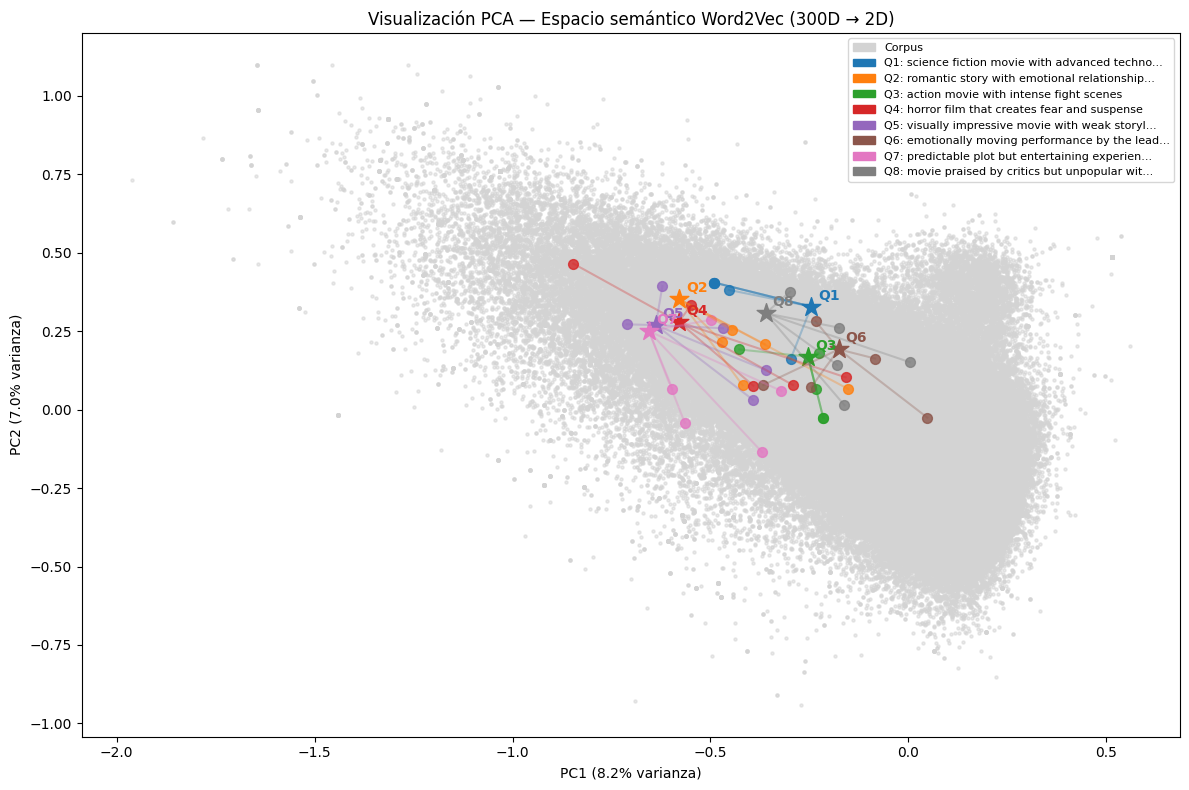

In [84]:
# --- 10.3  Mapa semántico: corpus + consultas + Top-5 ---
# Usamos la paleta de colores por defecto
COLORS = plt.cm.tab10.colors

fig, ax = plt.subplots(figsize=(12, 8))

# Corpus de fondo (gris simple)
ax.scatter(coords[:, 0], coords[:, 1], s=5, c='lightgray', alpha=0.5)

legend_handles = [mpatches.Patch(color='lightgray', label='Corpus')]

for i, (qid, query) in enumerate(QUERIES.items()):
    color = COLORS[i % len(COLORS)]

    # Índices Top-K reales en df_corpus
    q_emb   = query_embs[i].reshape(1, -1)
    sims    = cosine_similarity(q_emb, doc_embeddings)[0]
    top_idx = np.argsort(sims)[::-1][:K]

    # Documentos recuperados
    ax.scatter(coords[top_idx, 0], coords[top_idx, 1], 
               s=50, c=[color], alpha=0.8)

    # Líneas consulta → documentos
    for idx in top_idx:
        ax.plot([query_coords[i, 0], coords[idx, 0]],
                [query_coords[i, 1], coords[idx, 1]],
                color=color, alpha=0.3)

    # Estrella de la consulta
    ax.scatter(query_coords[i, 0], query_coords[i, 1], 
               s=200, c=[color], marker='*')

    # Etiqueta simple
    ax.annotate(qid,
                xy=(query_coords[i, 0], query_coords[i, 1]),
                xytext=(5, 5), textcoords='offset points',
                color=color, fontweight='bold')

    label = query[:42] + '...' if len(query) > 42 else query
    legend_handles.append(mpatches.Patch(color=color, label=f'{qid}: {label}'))

# Títulos y etiquetas por defecto
ax.set_title('Visualización PCA — Espacio semántico Word2Vec (300D → 2D)')
ax.set_xlabel(f'PC1 ({var_exp[0]:.1f}% varianza)')
ax.set_ylabel(f'PC2 ({var_exp[1]:.1f}% varianza)')

ax.legend(handles=legend_handles, loc='best', fontsize=8)

plt.tight_layout()
plt.show()

,Consulta,Sim. Máxima (Top-1),Sim. Promedio Top-5
0,Q1,0.832900,0.811600
1,Q2,0.807000,0.777100
2,Q3,0.829500,0.796500
3,Q4,0.833000,0.810400
4,Q5,0.826300,0.805400
5,Q6,0.745000,0.741200
6,Q7,0.836700,0.803200
7,Q8,0.764400,0.740500


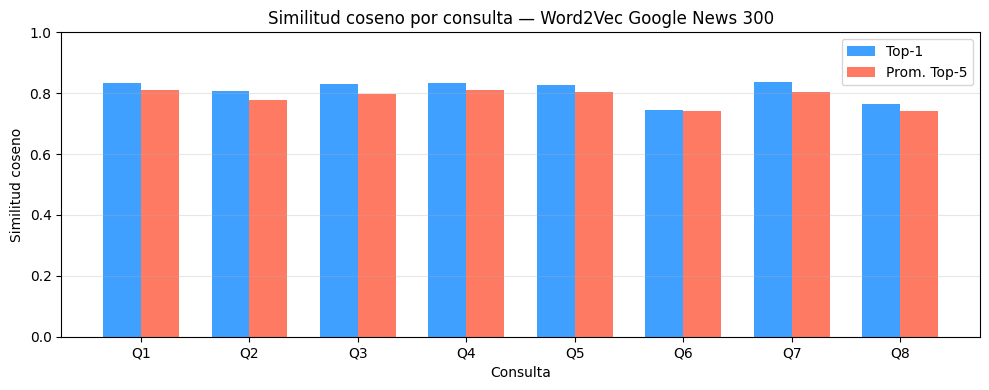

In [85]:
# --- 10.4  Análisis de similitud por consulta ---
analysis_rows = []
for qid, df_r in results.items():
    analysis_rows.append({
        'Consulta'           : qid,
        'Sim. Máxima (Top-1)': round(df_r['Similitud'].max(),  4),
        'Sim. Promedio Top-5': round(df_r['Similitud'].mean(), 4)
    })

df_analysis = pd.DataFrame(analysis_rows)

display(
    df_analysis.style
        .background_gradient(subset=['Sim. Máxima (Top-1)', 'Sim. Promedio Top-5'], cmap='Blues')
        .set_properties(**{'text-align': 'center'})
)

fig, ax = plt.subplots(figsize=(10, 4))
x     = np.arange(len(df_analysis))
w     = 0.35

# Colores simples, claros y directos
ax.bar(x - w/2, df_analysis['Sim. Máxima (Top-1)'],  w, label='Top-1',      color='dodgerblue', alpha=0.85)
ax.bar(x + w/2, df_analysis['Sim. Promedio Top-5'], w, label='Prom. Top-5', color='tomato', alpha=0.85)

ax.set_xlabel('Consulta')
ax.set_ylabel('Similitud coseno')
ax.set_title('Similitud coseno por consulta — Word2Vec Google News 300')
ax.set_xticks(x)
ax.set_xticklabels(df_analysis['Consulta'])
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()

# Se retiró plt.savefig()
plt.show()

---
## Analisis de resultados

- Se implementó un pipeline completo de recuperación de información usando **Word2Vec Google News 300**.
- El embedding de cada documento se obtiene mediante **mean pooling**: promedio de los vectores de sus tokens presentes en el vocabulario del modelo.
- La similitud coseno permite ordenar documentos de manera coherente con la intención semántica de cada consulta.
- La visualización PCA (300D → 2D) muestra que consultas de géneros distintos recuperan documentos en regiones diferentes del espacio vectorial, validando la capacidad discriminativa de los embeddings.
- Word2Vec captura relaciones semánticas léxicas (sinónimos, co-ocurrencias) sin necesidad de contexto de oración completa, lo que lo hace robusto para vocabulario de dominio específico como reseñas cinematográficas.
- El impacto del preprocesamiento: Se demostró que aplicar una limpieza "suave" (conservando la morfología original de las palabras) es vital al utilizar modelos preentrenados como Word2Vec. Técnicas tradicionales más agresivas, como el stemming o la lematización, recortan tokens válidos y los excluyen del vocabulario del modelo, lo que degrada severamente la calidad de la representación vectorial del documento.